# SA 1.2 — Nested Spheres: Co-occurrence of Sphere Counts in the Same Books

**Question:** Which numbers of spheres (CK_07–CK_12) appear together in the same books?
For each book, which CKs does it have, and which combinations are most common?


## 1. Imports


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from itertools import combinations


## 2. Load data


In [2]:
df    = pd.read_csv('../DATA/02_image_clusters/full_image_data_feb_25.csv')
books = pd.read_csv('../DATA/01_corpus_metadata/full_book_data_feb_25.csv')
df['printer']   = df['book'].map(books.set_index('book')['printers'])
df['publisher'] = df['book'].map(books.set_index('book')['publishers'])

# The nested-sphere CKs, ordered by sphere count
SPHERE_CKS = [
    'CK_07 Spheres',
    'CK_08 Spheres',
    'CK_09 Spheres',
    'CK_10 Spheres',
    'CK_11 Spheres',
    'CK_12 Spheres',
]

# All rows that carry at least one of these CKs
sphere_df = df[df['cks'].isin(SPHERE_CKS)].copy()

print(f'Rows with sphere CKs : {len(sphere_df)}')
print(f'Unique books         : {sphere_df["bid"].nunique()}')
print(f'Unique images        : {sphere_df["images"].nunique()}')
print()
print('Images per CK:')
print(sphere_df.groupby('cks')['images'].nunique().reindex(SPHERE_CKS))


Rows with sphere CKs : 398
Unique books         : 314
Unique images        : 392

Images per CK:
cks
CK_07 Spheres      3
CK_08 Spheres     20
CK_09 Spheres     83
CK_10 Spheres    227
CK_11 Spheres     37
CK_12 Spheres     22
Name: images, dtype: int64


## 3. Which sphere-count CKs appear together in the same book?


In [3]:
# For each book: the SET of sphere CKs it contains
book_cks = (
    sphere_df
    .groupby('bid')['cks']
    .apply(lambda x: frozenset(x.unique()))
)

# Add place/year for context
book_meta = (
    sphere_df
    .drop_duplicates('bid')
    .set_index('bid')[['place', 'year', 'place_category', 'printer']]
)

book_cks_df = book_cks.rename('sphere_cks').to_frame().join(book_meta)

# Human-readable: just the numbers (07, 08 …)
book_cks_df['sphere_counts'] = book_cks_df['sphere_cks'].apply(
    lambda s: ' + '.join(sorted(c.replace('CK_','').replace(' Spheres','') for c in s))
)

# Count how many books share each combination
combo_counts = (
    book_cks_df['sphere_counts']
    .value_counts()
    .rename_axis('combination')
    .reset_index(name='n_books')
)

print(f'Distinct combinations found: {len(combo_counts)}')
display(combo_counts)


Distinct combinations found: 11


,combination,n_books
0,10,163
1,09,77
2,11,29
3,08,18
4,12,16
5,10 + 11,3
6,07 + 11,3
7,09 + 10,2
8,09 + 11,1
9,08 + 10,1


## 4. Co-occurrence matrix (how often do pairs appear in the same book?)


Co-occurrence matrix (number of books):


,07,08,09,10,11,12
07,3,0,0,0,3,0
08,0,19,0,1,0,0
09,0,0,80,2,1,0
10,0,1,2,169,3,0
11,3,0,1,3,37,1
12,0,0,0,0,1,17


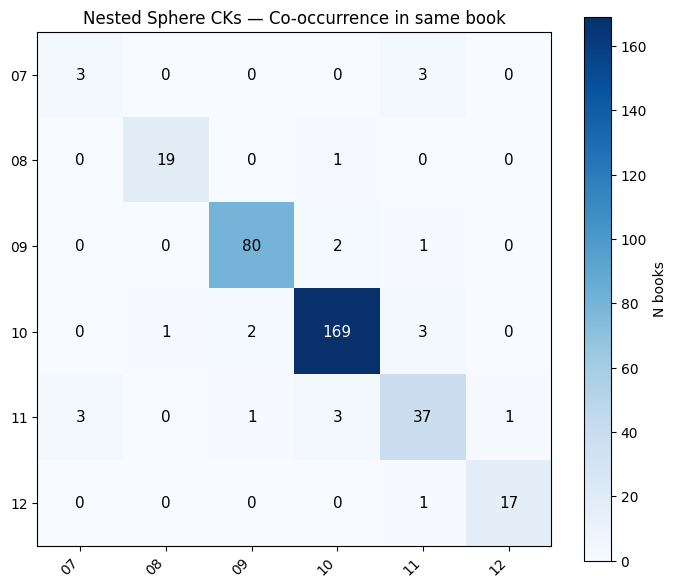

In [4]:
# Build a pairwise co-occurrence matrix
labels = [c.replace('CK_','').replace(' Spheres','') for c in SPHERE_CKS]
matrix = pd.DataFrame(0, index=labels, columns=labels)

for cks_set in book_cks_df['sphere_cks']:
    ck_list = list(cks_set)
    # diagonal: solo counts
    for ck in ck_list:
        lbl = ck.replace('CK_','').replace(' Spheres','')
        matrix.loc[lbl, lbl] += 1
    # pairs
    for a, b in combinations(ck_list, 2):
        la = a.replace('CK_','').replace(' Spheres','')
        lb = b.replace('CK_','').replace(' Spheres','')
        matrix.loc[la, lb] += 1
        matrix.loc[lb, la] += 1

print('Co-occurrence matrix (number of books):')
display(matrix)

# Heatmap
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(matrix.values, cmap='Blues')
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
plt.colorbar(im, ax=ax, label='N books')
for i in range(len(labels)):
    for j in range(len(labels)):
        v = matrix.values[i, j]
        ax.text(j, i, str(v), ha='center', va='center',
                fontsize=11, color='white' if v > matrix.values.max()/2 else 'black')
ax.set_title('Nested Sphere CKs — Co-occurrence in same book', fontsize=12)
plt.tight_layout()
plt.show()


## 5. Book list per combination


In [5]:
# Show books grouped by their combination, sorted by most common first
for combo in combo_counts['combination']:
    books_in_combo = (
        book_cks_df[book_cks_df['sphere_counts'] == combo]
        .sort_values('year')[['place', 'year', 'printer']]
        .reset_index()
    )
    print(f'\n── {combo}  ({len(books_in_combo)} books) ──')
    display(books_in_combo)



── 10  (163 books) ──


,bid,place,year,printer
0,1772,Ingolstadt,1526,"Apianus, Petrus"
1,2091,Wittenberg,1531,"Klug, Joseph"
2,1879,Venice,1532,Company Giovanni Antonio Nicolini da Sabbio & ...
3,1880,Wittenberg,1534,"Klug, Joseph"
4,1881,Venice,1534,Company Giovanni Antonio Nicolini da Sabbio & ...
...,...,...,...,...
158,2189,Leiden,1626,Company Bonaventura Elsevier & Abraham Elsevier
159,2115,Wittenberg,1629,"Fincelius, Hiob Wilhelm"
160,1899,Wittenberg,1629,Company Widow & heirs of Zacharias I. Schürer
161,1799,Leiden,1639,Company Bonaventura Elsevier & Abraham Elsevier



── 09  (77 books) ──


,bid,place,year,printer
0,1938,Ferrara,1472,"Belfortis, Andreas"
1,1611,Venice,1478,Adam of Rottweil
2,1940,Venice,1478,"Renner, Franz"
3,1613,Bologna,1480,"Fuscus, Dominicus"
4,1923,Venice,1482,"Ratdolt, Erhard"
...,...,...,...,...
72,2240,Antwerp,1548,"Loe, Jan vander"
73,2217,Milan,1550,Company Valerio Meda & brothers
74,1761,Dijon,1619,"Guyot, Claude"
75,1763,Salamanca,1629,"Taberniel, Jacinto"



── 11  (29 books) ──


...

,bid,place,year,printer
0,1699,Florence,1550,"Torrentino, Lorenzo"



── 08 + 10  (1 books) ──


,bid,place,year,printer
0,1854,Lyon,1582,"Béraud, Symphorien"



── 11 + 12  (1 books) ──


,bid,place,year,printer
0,1950,Madrid,1599,"Herrera, Juan de"


## 6. Text parts per sphere count — when do they first appear and how do they spread?

Each subplot covers one CK (07–12 Spheres).
- **X axis** = year
- **Y axis** = place (city)
- **Color** = text part (custom_identifier)
- **Hover / annotation** = part_or_adaption_label

One dot = one unique book.


In [6]:
# ── Prepare: one row per (CK, book) ────────────────────────────
books_per_ck = (
    sphere_df
    .drop_duplicates(subset=['cks', 'bid'])
    [['cks', 'bid', 'year', 'place', 'place_category',
      'custom_identifier', 'part_or_adaption_label', 'printer']]
    .dropna(subset=['year', 'place'])
    .copy()
)

# Short label: just the number from custom_identifier + abbreviated title
def short_label(row):
    cid = row['custom_identifier']
    lbl = row['part_or_adaption_label']
    if pd.isna(cid) or pd.isna(lbl):
        return 'Unknown'
    # Take first ~35 chars of label
    return f"{int(cid)} — {str(lbl)[:35]}"

books_per_ck['text_part'] = books_per_ck.apply(short_label, axis=1)

# Assign a stable numeric color index per text_part
all_parts = sorted(books_per_ck['text_part'].unique())
part_to_idx = {p: i for i, p in enumerate(all_parts)}
books_per_ck['part_idx'] = books_per_ck['text_part'].map(part_to_idx)

print(f'Unique text parts across all sphere CKs: {len(all_parts)}')
print(books_per_ck.groupby('cks')['text_part'].nunique().reindex(SPHERE_CKS))


Unique text parts across all sphere CKs: 86
cks
CK_07 Spheres     2
CK_08 Spheres    10
CK_09 Spheres    25
CK_10 Spheres    43
CK_11 Spheres    16
CK_12 Spheres     3
Name: text_part, dtype: int64


/var/folders/6r/8tpplrhn0rlglqf49qymjfmc0000gn/T/ipykernel_8708/3358920680.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', len(all_parts))


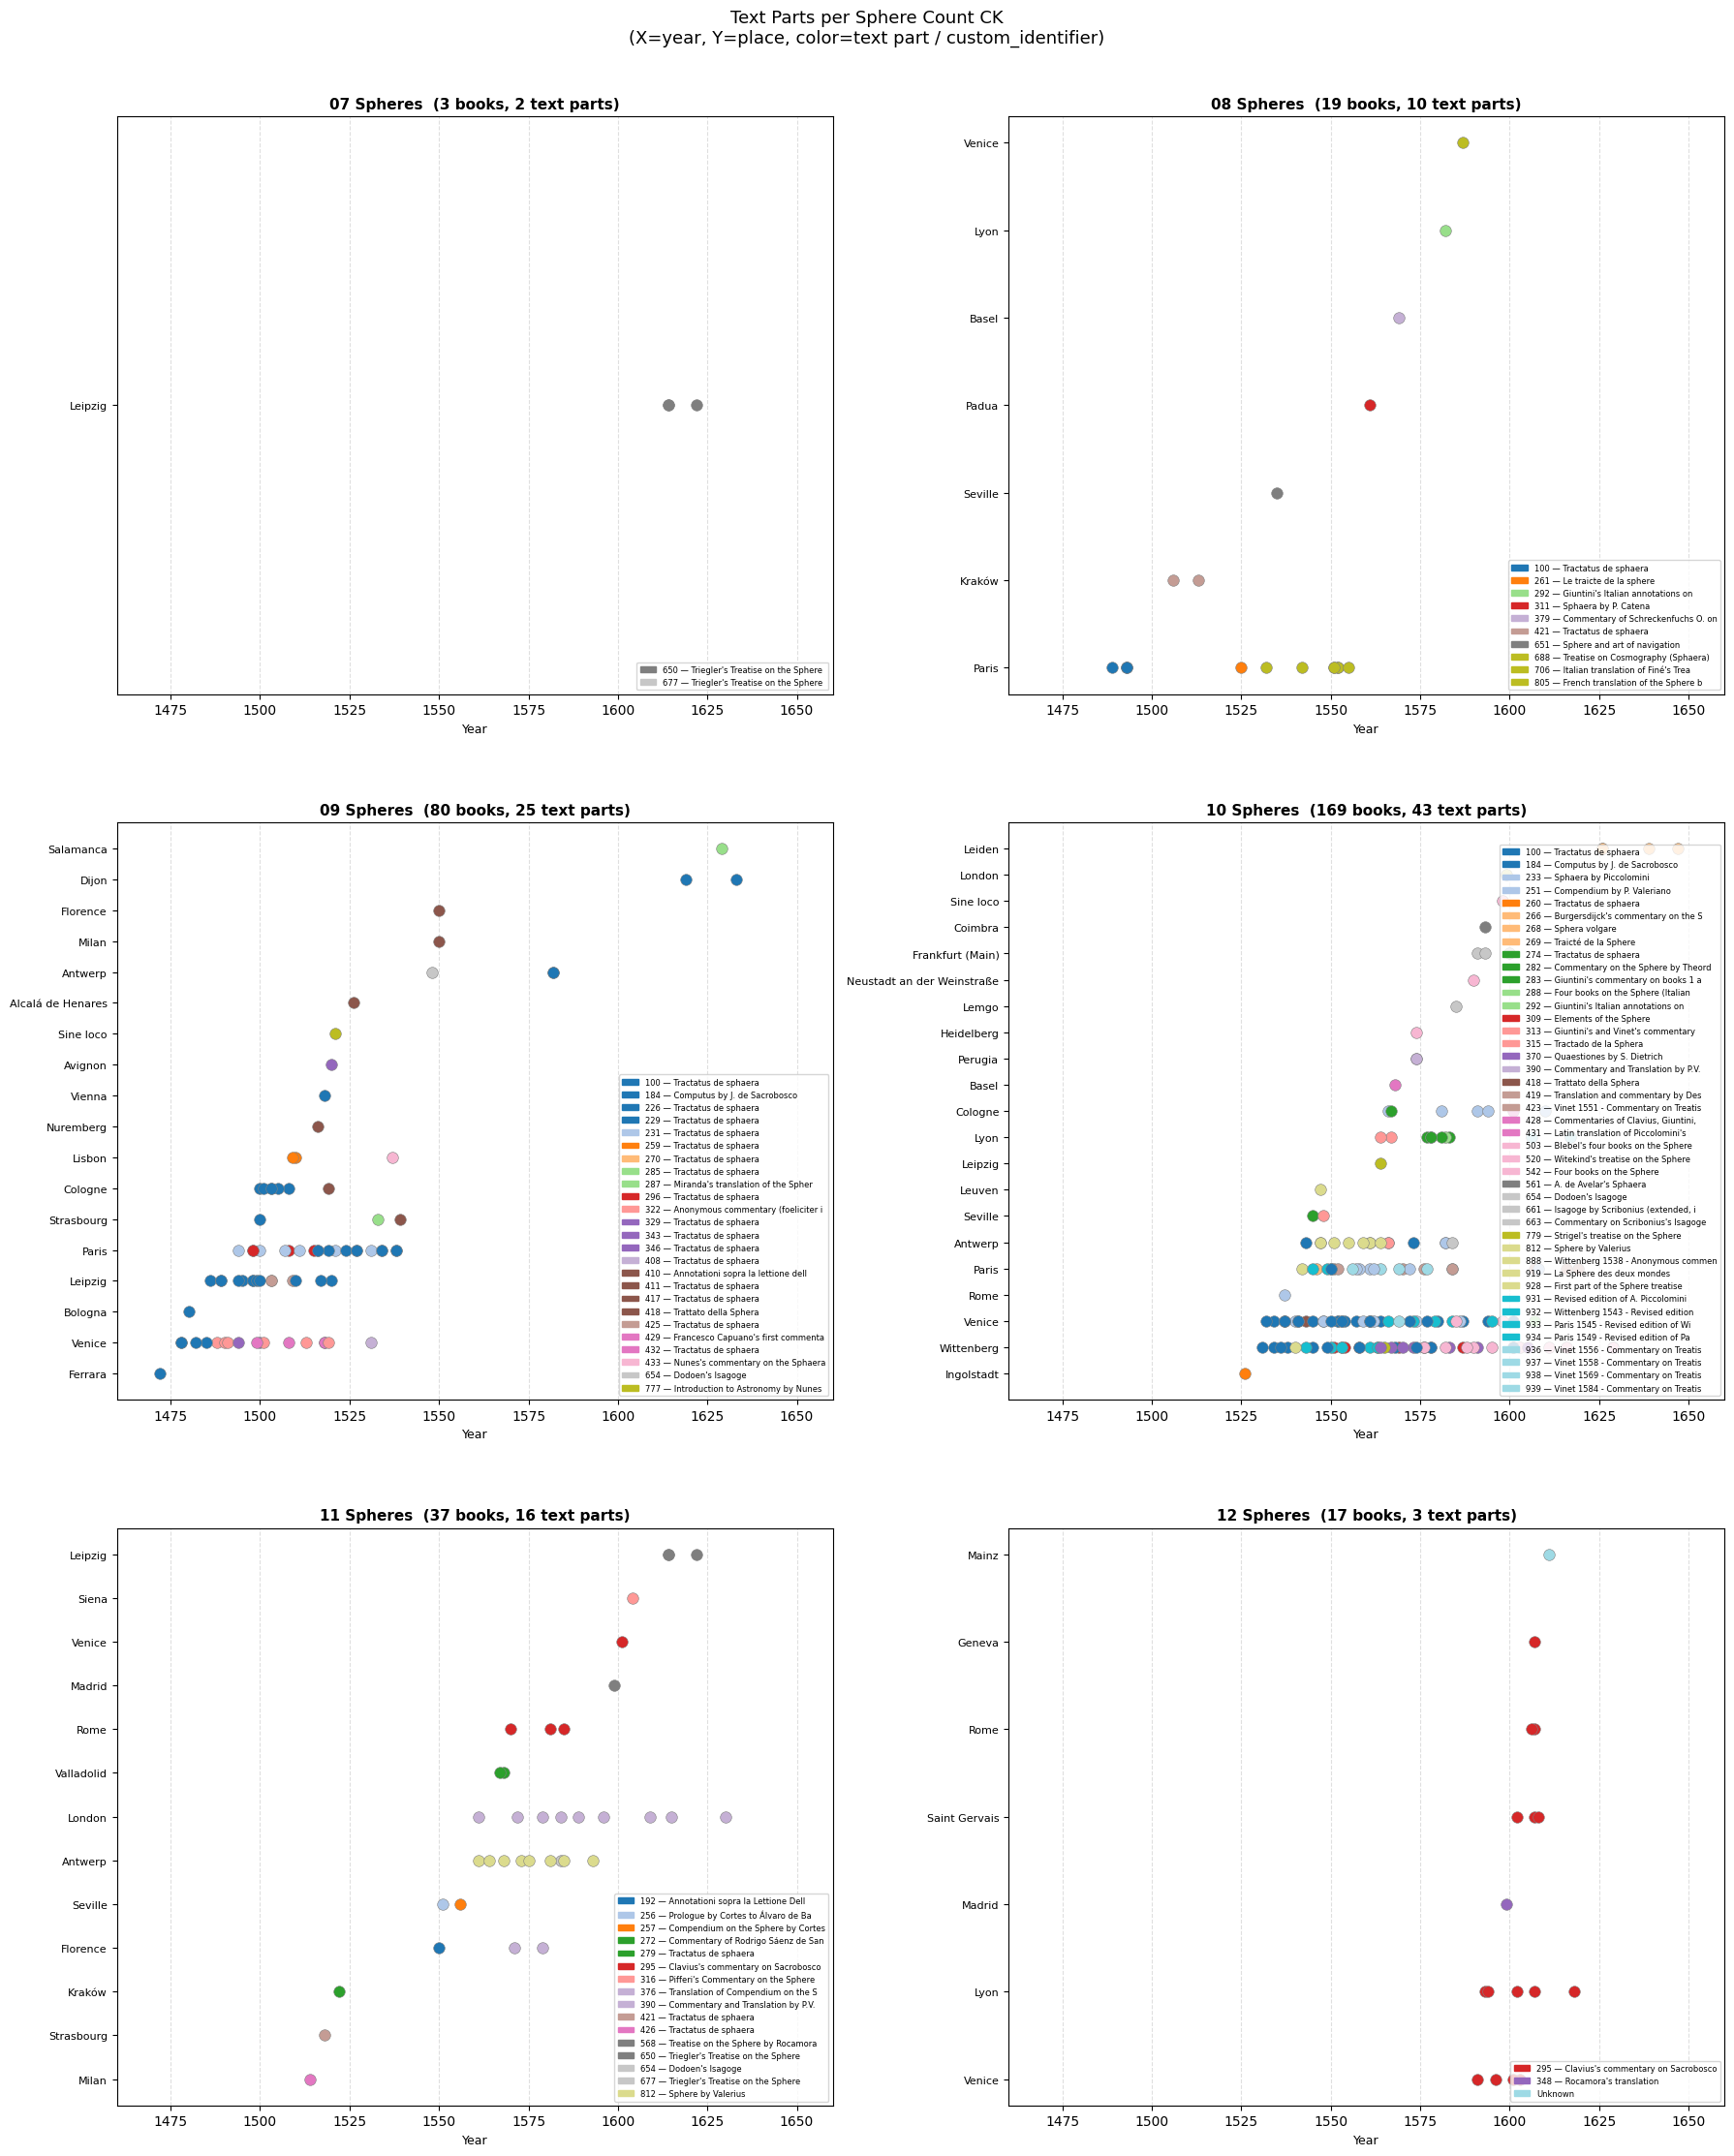

Saved: SA_1.2_text_parts_scatter.png


In [7]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches
import numpy as np

cmap = cm.get_cmap('tab20', len(all_parts))

fig, axes = plt.subplots(3, 2, figsize=(18, 22), sharey=False)
axes = axes.flatten()

for ax, ck in zip(axes, SPHERE_CKS):
    sub = books_per_ck[books_per_ck['cks'] == ck].copy()
    ck_label = ck.replace('CK_', '')

    # Ordered places: sort by earliest year they appear
    place_order = (
        sub.groupby('place')['year'].min()
        .sort_values().index.tolist()
    )
    place_to_y = {p: i for i, p in enumerate(place_order)}
    sub['y'] = sub['place'].map(place_to_y)

    # Scatter: one dot per book, colored by text part
    for _, row in sub.iterrows():
        color = cmap(row['part_idx'] / max(len(all_parts) - 1, 1))
        ax.scatter(row['year'], row['y'], color=color,
                   s=70, edgecolors='grey', linewidths=0.4, zorder=3)

    ax.set_yticks(range(len(place_order)))
    ax.set_yticklabels(place_order, fontsize=8)
    ax.set_xlabel('Year', fontsize=9)
    ax.set_title(f'{ck_label}  ({sub["bid"].nunique()} books, '
                 f'{sub["text_part"].nunique()} text parts)',
                 fontsize=11, fontweight='bold')
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    ax.set_xlim(1460, 1660)

    # Mini legend inside each subplot (top-right, max 10 entries)
    parts_in_ck = sub[['text_part', 'part_idx']].drop_duplicates().sort_values('part_idx')
    handles = [
        mpatches.Patch(
            color=cmap(row['part_idx'] / max(len(all_parts) - 1, 1)),
            label=row['text_part'][:40]
        )
        for _, row in parts_in_ck.iterrows()
    ]
    ax.legend(handles=handles, fontsize=6, loc='lower right',
              framealpha=0.8, ncol=1)

plt.suptitle('Text Parts per Sphere Count CK\n'
             '(X=year, Y=place, color=text part / custom_identifier)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('SA_1.2_text_parts_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: SA_1.2_text_parts_scatter.png')


## 7. First appearances — which text part introduces each sphere count?


In [8]:
# For each CK: first book per text_part (sorted by year)
first_appearances = (
    books_per_ck
    .sort_values('year')
    .groupby(['cks', 'text_part'])
    .first()
    .reset_index()
    [['cks', 'text_part', 'year', 'place', 'printer']]
    .sort_values(['cks', 'year'])
)

for ck in SPHERE_CKS:
    sub = first_appearances[first_appearances['cks'] == ck]
    print(f'\n── {ck} — first book per text part ──')
    display(sub[['text_part','year','place','printer']].reset_index(drop=True))



── CK_07 Spheres — first book per text part ──


,text_part,year,place,printer
0,650 — Triegler's Treatise on the Sphere (,1614,Leipzig,"Hermann, Johann"
1,677 — Triegler's Treatise on the Sphere (,1614,Leipzig,"Hermann, Johann"



── CK_08 Spheres — first book per text part ──


,text_part,year,place,printer
0,100 — Tractatus de sphaera,1489,Paris,"Hopyl, Wolfgang"
1,421 — Tractatus de sphaera,1506,Kraków,"Haller, Jan"
2,261 — Le traicte de la sphere,1525,Paris,"Bois, Simon du"
3,688 — Treatise on Cosmography (Sphaera),1532,Paris,"Morrhy, Gérard"
4,651 — Sphere and art of navigation,1535,Seville,"Cromberger, Juan"
5,805 — French translation of the Sphere by,1551,Paris,"Vascosan, Michel"
6,311 — Sphaera by P. Catena,1561,Padua,"Percacino, Grazioso"
7,379 — Commentary of Schreckenfuchs O. on,1569,Basel,"Petri, Heinrich"
8,292 — Giuntini's Italian annotations on t,1582,Lyon,"Béraud, Symphorien"
9,706 — Italian translation of Finé's Treat,1587,Venice,"Franceschi, Francesco de"



── CK_09 Spheres — first book per text part ──


...

,text_part,year,place,printer
0,260 — Tractatus de sphaera,1526,Ingolstadt,"Apianus, Petrus"
1,100 — Tractatus de sphaera,1531,Wittenberg,"Klug, Joseph"
2,251 — Compendium by P. Valeriano,1537,Rome,"Blado, Antonio"
3,268 — Sphera volgare,1537,Venice,"Zanetti, Bartolomeo"
4,184 — Computus by J. de Sacrobosco,1538,Wittenberg,"Klug, Joseph"
5,233 — Sphaera by Piccolomini,1540,Venice,Company Giovanni Antonio Volpini & Domenico Vo...
6,888 — Wittenberg 1538 - Anonymous comment,1540,Wittenberg,"Klug, Joseph"
7,418 — Trattato della Sphera,1543,Venice,Company Francesco Brucioli & brothers
8,932 — Wittenberg 1543 - Revised edition o,1543,Wittenberg,"Seitz, Peter I."
9,274 — Tractatus de sphaera,1545,Seville,"León, Juan de"



── CK_11 Spheres — first book per text part ──


,text_part,year,place,printer
0,426 — Tractatus de sphaera,1514,Milan,"Ponte, Gottardo da"
1,421 — Tractatus de sphaera,1518,Strasbourg,"Knobloch I, Johann"
2,279 — Tractatus de sphaera,1522,Kraków,"Haller, Jan"
3,192 — Annotationi sopra la Lettione Della,1550,Florence,"Torrentino, Lorenzo"
4,256 — Prologue by Cortes to Álvaro de Baz,1551,Seville,"Alvares, António"
5,257 — Compendium on the Sphere by Cortes,1556,Seville,"Alvares, António"
6,376 — Translation of Compendium on the Sp,1561,London,"Jugge, Richard"
7,812 — Sphere by Valerius,1561,Antwerp,"Plantin, Christophe"
8,272 — Commentary of Rodrigo Sáenz de Sant,1567,Valladolid,"Ghemart, Adrián"
9,295 — Clavius's commentary on Sacrobosco',1570,Rome,"Eliano, Vittorio"



── CK_12 Spheres — first book per text part ──


,text_part,year,place,printer
0,295 — Clavius's commentary on Sacrobosco',1591,Venice,"Ciotti, Giovanni Battista"
1,348 — Rocamora's translation,1599,Madrid,"Herrera, Juan de"
2,Unknown,1611,Mainz,"Eltz, Reinhard"


## Standalone: CK_10 Spheres scatter plot (print-ready)


/var/folders/6r/8tpplrhn0rlglqf49qymjfmc0000gn/T/ipykernel_8708/218459730.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', len(all_parts))


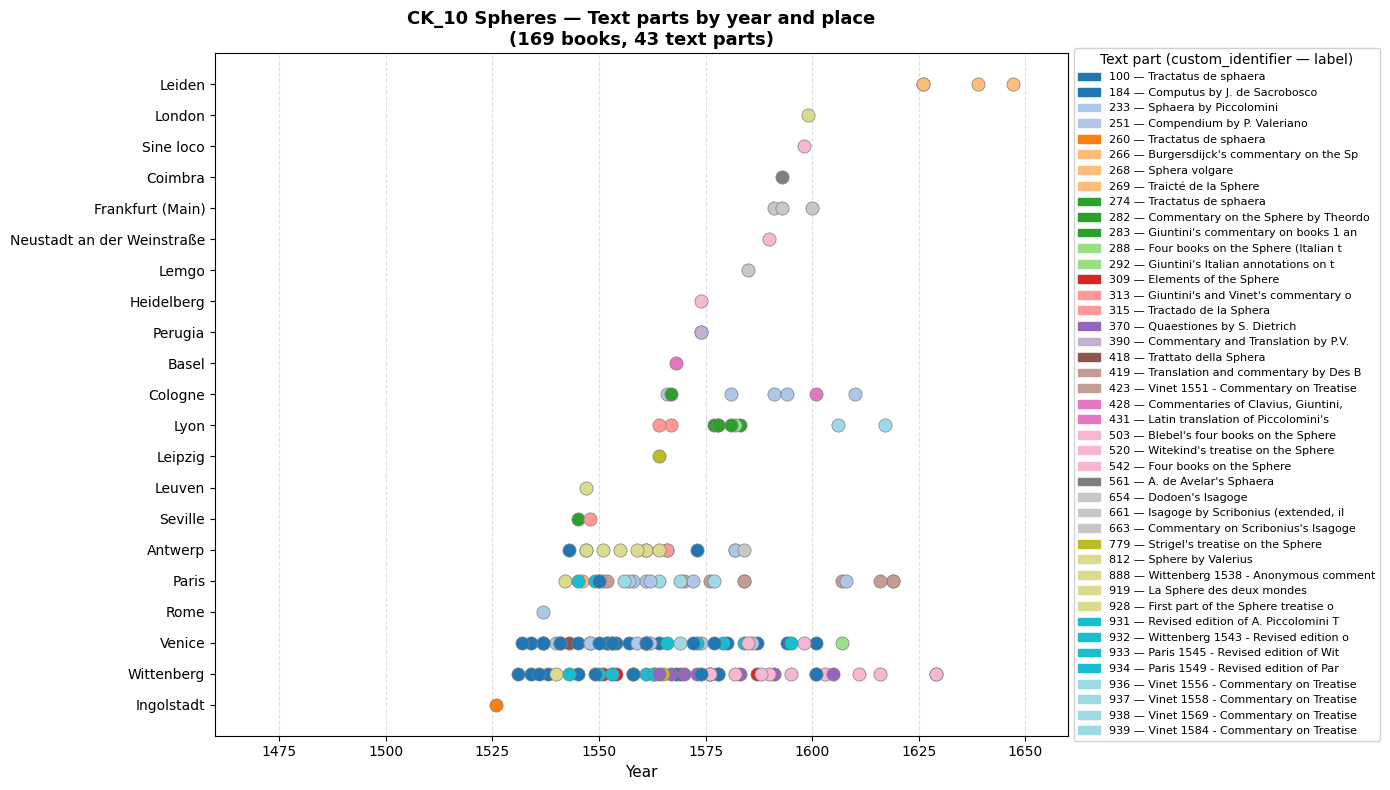

Saved: SA_1.2_10_spheres_text_parts.png


In [10]:
# ── Standalone: CK_10 Spheres scatter plot ──────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm

CK = 'CK_10 Spheres'
OUT = 'SA_1.2_10_spheres_text_parts.png'

sub = books_per_ck[books_per_ck['cks'] == CK].copy()

# Y-axis: places ordered by first year of appearance
place_order = (
    sub.groupby('place')['year'].min()
    .sort_values().index.tolist()
)
sub['y'] = sub['place'].map({p: i for i, p in enumerate(place_order)})

cmap = cm.get_cmap('tab20', len(all_parts))

fig, ax = plt.subplots(figsize=(14, 8))

for _, row in sub.iterrows():
    color = cmap(row['part_idx'] / max(len(all_parts) - 1, 1))
    ax.scatter(row['year'], row['y'], color=color,
               s=90, edgecolors='grey', linewidths=0.5, zorder=3)

ax.set_yticks(range(len(place_order)))
ax.set_yticklabels(place_order, fontsize=10)
ax.set_xlabel('Year', fontsize=11)
ax.set_title(
    f'CK_10 Spheres — Text parts by year and place\n'
    f'({sub["bid"].nunique()} books, {sub["text_part"].nunique()} text parts)',
    fontsize=13, fontweight='bold'
)
ax.set_xlim(1460, 1660)
ax.grid(axis='x', linestyle='--', alpha=0.4)

# Legend - placed outside the plot area to the right
parts_in_ck = sub[['text_part', 'part_idx']].drop_duplicates().sort_values('part_idx')
handles = [
    mpatches.Patch(
        color=cmap(row['part_idx'] / max(len(all_parts) - 1, 1)),
        label=row['text_part'][:50]
    )
    for _, row in parts_in_ck.iterrows()
]
ax.legend(handles=handles, fontsize=8, loc='center left', bbox_to_anchor=(1, 0.5),
          framealpha=0.9, title='Text part (custom_identifier — label)')

plt.tight_layout()

plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/corrections_round/SA_1.2_10_spheres_text_parts.png', dpi=300)

# plt.savefig(OUT, dpi=300, bbox_inches='tight')

plt.show()
print(f'Saved: {OUT}')